<a href="https://colab.research.google.com/github/aminatahir-0/Student-Engagement-Analytics-Machine-Learning/blob/main/Student_Engagement_analysis(machine_learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Engagement Analysis: From EDA to Machine Learning
**Author:** Amina Tahir

### Abstract
This study examines the key factors influencing internship completion and dropout rates using an online learning engagement dataset of 2,800 records. Through data cleaning, feature engineering, and visualization in Python (Pandas and Matplotlib), the initial exploratory data analysis (EDA) revealed a high overall dropout rate of 57.8%, with individual engagement habits operating largely independently.

To take this analysis further, we built a predictive Random Forest machine learning model. While the model initially achieved 100% accuracy, feature importance and drop-feature testing proved that cumulative **course_progress_percent** is the definitive driver of success; removing it caused model accuracy to drop to 53.57%. Together, these findings demonstrate that while individual habits matter, student retention systems must rely on unified, cumulative progress tracking to accurately identify and support at-risk participants.

## Data Loading & Feature Engineering
The dataset is loaded directly from the project's GitHub repository. To align with the analytical objectives, we perform the following data transformations:
* **Completion Status:** Engineered a new feature classifying students with >= 60% progress as 'Completed'.
* **Standardization:** Renamed core columns (e.g., `course_category` to `Department`) for clarity.
* **Categorization:** Binned continuous mentor interaction data into 'Low', 'Medium', and 'High' tiers for clear visual comparison.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/aminatahir-0/Student-Engagement-Analytics/refs/heads/main/online_learning_engagement_dropout_risk-selected-columns.csv"
df = pd.read_csv(url)

# Create the 'Status' column (Pass/Fail)
df['Status'] = df['course_progress_percent'].apply(lambda x: 'Completed' if x >= 60 else 'Dropped Out')

# Rename columns
df.rename(columns={
    'course_category': 'Department',
    'avg_session_minutes': 'Duration(minutes)',
    'forum_interactions': 'Mentor_Interaction'
}, inplace=True)

# Group mentor interactions into Low, Medium, High to avoid distorted charts.
df['Mentor_Interaction_Level'] = pd.qcut(df['Mentor_Interaction'], q=3, labels=['Low', 'Medium', 'High'])

df.head()

,student_id,Department,login_frequency_per_week,Duration(minutes),course_progress_percent,assignments_completed,quiz_average_score,Mentor_Interaction,video_watch_percent,device_type,Status,Mentor_Interaction_Level
0,1,Design,14,17,51,7,60.42,14,23,Desktop,Dropped Out,Low
1,2,AI & ML,8,26,1,10,77.25,33,29,Tablet,Dropped Out,Medium
2,3,Business,6,26,24,1,93.46,23,82,Desktop,Dropped Out,Medium
3,4,AI & ML,5,99,12,7,69.77,32,92,Desktop,Dropped Out,Medium
4,5,AI & ML,13,150,97,3,89.48,40,34,Tablet,Completed,High


## Data Profiling & Quality Check

In [3]:
# Show the number of rows and columns
df.shape

# Show a summary of all columns
df.info()

# Count the null values in every column
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   student_id                2800 non-null   int64   
 1   Department                2800 non-null   object  
 2   login_frequency_per_week  2800 non-null   int64   
 3   Duration(minutes)         2800 non-null   int64   
 4   course_progress_percent   2800 non-null   int64   
 5   assignments_completed     2800 non-null   int64   
 6   quiz_average_score        2800 non-null   float64 
 7   Mentor_Interaction        2800 non-null   int64   
 8   video_watch_percent       2800 non-null   int64   
 9   device_type               2800 non-null   object  
 10  Status                    2800 non-null   object  
 11  Mentor_Interaction_Level  2800 non-null   category
dtypes: category(1), float64(1), int64(7), object(3)
memory usage: 243.6+ KB


,0
student_id,0
Department,0
login_frequency_per_week,0
Duration(minutes),0
course_progress_percent,0
assignments_completed,0
quiz_average_score,0
Mentor_Interaction,0
video_watch_percent,0
device_type,0


*   **Total Records:** 2,800 students.
*   **Integrity:** The dataset is complete with no missing values (all counts are 2,800).

In [4]:
# Get a statistical summary of all the numerical columns
df.describe()

,student_id,login_frequency_per_week,Duration(minutes),course_progress_percent,assignments_completed,quiz_average_score,Mentor_Interaction,video_watch_percent
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,1400.500000,7.498571,94.236786,50.601786,5.612857,70.130061,24.644286,60.263571
std,808.434702,4.032557,48.937770,29.157302,3.445816,17.395494,14.642357,23.583951
min,1.000000,1.000000,10.000000,0.000000,0.000000,40.010000,0.000000,20.000000
25%,700.750000,4.000000,52.000000,25.000000,3.000000,55.110000,12.000000,39.000000
50%,1400.500000,8.000000,94.000000,52.000000,6.000000,69.910000,24.000000,60.000000
75%,2100.250000,11.000000,136.000000,76.000000,9.000000,85.515000,37.000000,81.000000
max,2800.000000,14.000000,179.000000,100.000000,11.000000,99.980000,49.000000,100.000000




**Course Progress:** The average course progress (mean) sits at 50.6%, with a median (50%) of 52.0%, showing a fairly balanced split across the program.

**Login Frequency:** On average, participants log in about 7.5 times per week, ranging from a minimum of 1 to a maximum of 14 times per week.

**Quiz Performance:** The average quiz score is 70.1%, with scores ranging from a minimum of 40% up to nearly 100%.

**Session Duration:** The average session length is about 94.2 minutes, with 50% of sessions lasting under 94 minutes and a maximum length of 179 minutes.

___
# Overall Completion vs. Dropout Rate

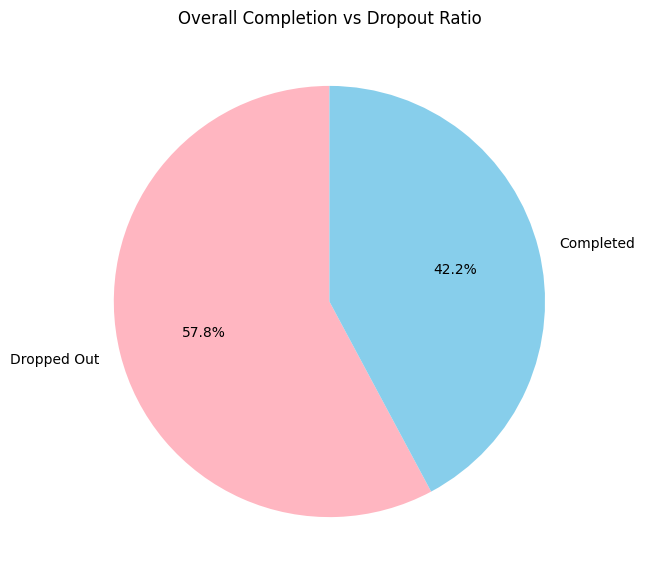

In [48]:
status_counts = df['Status'].value_counts()
plt.figure(figsize=(7, 7))
status_counts.plot(kind='pie',autopct='%1.1f%%', colors=['lightpink','skyblue'], startangle=90)
plt.title('Overall Completion vs Dropout Ratio')
plt.ylabel('')
plt.show()

**High Attrition Rate:** The majority of participants—57.8%—dropped out, indicating a significant retention challenge across the program.

**Lower Completion Rate:** Only 42.2% of participants successfully completed the program.

**Core Insight:** This baseline split establishes that dropouts outnumber completions by a substantial margin, highlighting the need to investigate underlying factors like departments and engagement levels to improve success rates.

___
#Completion Rate by Department

Status        Completed  Dropped Out
Department                          
AI & ML       43.033510    56.966490
Business      38.446970    61.553030
Data Science  42.504409    57.495591
Design        42.685026    57.314974
Programming   43.985637    56.014363


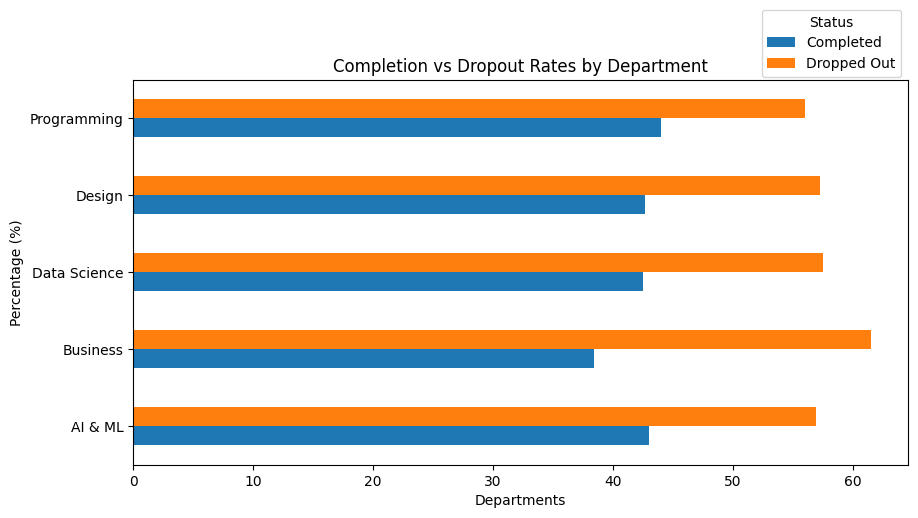

In [25]:
#  Group data by departments, count statuses, normalize to proportions, pivot into a table, and convert to percentages:
dept_status = df.groupby('Department')['Status'].value_counts(normalize=True).unstack() * 100 # unstack ( Pivots the data from a vertical list into a wide table columns format where each Status (Completed vs. Dropped Out) becomes its own column)
# (normalize=true) converts raw counts into proportions (percentages) so you can fairly compare groups regardless of their size.
print(dept_status)


# Plot as a bar chart
dept_status.plot(kind='barh',figsize=(10, 5))
plt.title('Completion vs Dropout Rates by Department')
plt.ylabel('Percentage (%)')
plt.xlabel('Departments')
plt.xticks(rotation=0)
plt.legend(title='Status',bbox_to_anchor=(1, 1.20), loc='upper right')

plt.show()

**High Overall Dropout Rates:** Across every single department, the orange bar (Dropped Out) is taller than the blue bar (Completed), showing that dropouts consistently outpace completions regardless of the field.

**Lowest Performing Area:** `Business` has the lowest completion rate (around 38%) and the highest dropout rate (surpassing 60%), making it the most vulnerable department.

**Highest Performing Area:** `Programming` achieves the highest completion rate (roughly 44%) and the lowest dropout rate among all categories.

**Consistent Trends:** AI & ML, Data Science, and Design all show very uniform results, hovering tightly around a 42-43% completion rate and a 57% dropout rate.
____
#Completion Rate by Mentor Interaction Level

/tmp/ipykernel_1423/93338233.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mentor_status = df.groupby('Mentor_Interaction_Level')['Status'].value_counts(normalize=True).unstack() * 100


Status                    Completed  Dropped Out
Mentor_Interaction_Level                        
Low                       44.700944    55.299056
Medium                    41.825902    58.174098
High                      39.889503    60.110497


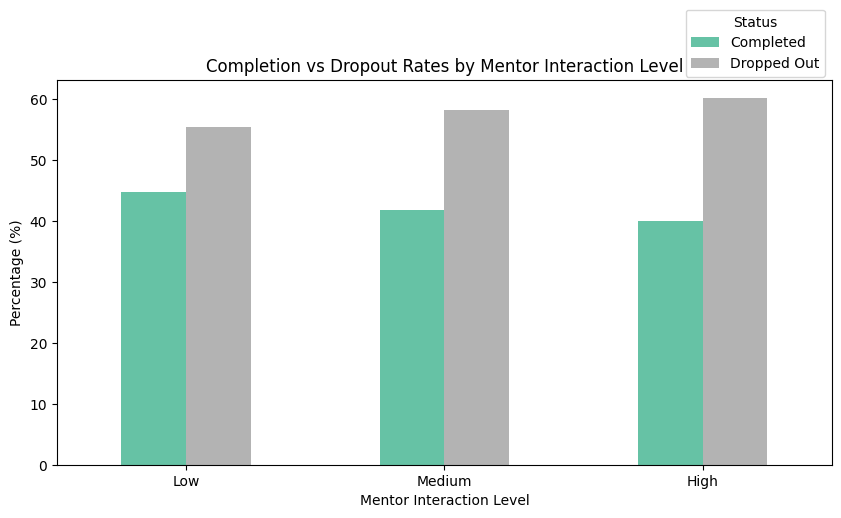

In [7]:
# Group by Mentor_Interaction_Level and Status, then convert to percentages
mentor_status = df.groupby('Mentor_Interaction_Level')['Status'].value_counts(normalize=True).unstack() * 100
print(mentor_status)

# Plot as a bar chart
mentor_status.plot(kind='bar',colormap='Set2',figsize=(10, 5))
plt.title('Completion vs Dropout Rates by Mentor Interaction Level')
plt.ylabel('Percentage (%)')
plt.xlabel('Mentor Interaction Level')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1, 1.20), loc='upper right')
plt.show()

**Direct Impact of Mentorship:** Unlike what is typically expected, higher mentor interaction does not decrease dropouts in this dataset; instead, the dropout rate slightly increases from Low interaction (around 55%) to High interaction (around 60%).

**Completion Trend:** The completion rate (blue bar) is highest at Low mentor interaction (roughly 45%) and gradually decreases as interaction increases, hitting its lowest point at High interaction (around 40%).

**Key Success Factor Insight:** This suggests that mentor interaction alone is not acting as a preventative measure for dropouts in this specific program, meaning management might need to look into how mentors are interacting or investigate other driving factors (like course duration or content difficulty) to improve success rates.

____
#Completion Rate by Duration(minutes)

Status          Completed  Dropped Out
Duration_Level                        
Short           41.371919    58.628081
Medium          41.825902    58.174098
Long            43.351351    56.648649


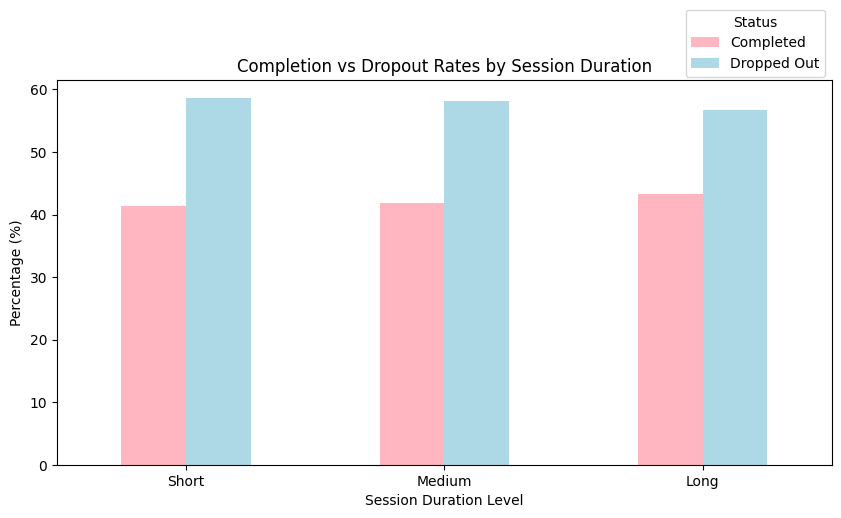

In [52]:
# Bin session duration into 3 clean categories: Short, Medium, Long
df['Duration_Level'] = pd.qcut(df['Duration(minutes)'], q=3, labels=['Short', 'Medium', 'Long'])

#  Group by the new binned column and Status, then convert to percentages
duration_status = df.groupby('Duration_Level', observed=True)['Status'].value_counts(normalize=True).unstack() * 100 ## observed=True tells Pandas to only calculate data for categories that actually have rows present, preventing warnings and empty groups
print(duration_status)

#  Plot as a clean bar chart
duration_status.plot(kind='bar', color=['lightpink','lightblue'],figsize=(10, 5))
plt.title('Completion vs Dropout Rates by Session Duration')
plt.ylabel('Percentage (%)')
plt.xlabel('Session Duration Level')
plt.xticks(rotation=0)
plt.legend(title='Status', bbox_to_anchor=(1, 1.20), loc='upper right')
plt.show()

**Minimal Impact of Duration:** Session duration has almost zero effect on whether an intern completes or drops out. The completion rates and dropout rates remain almost completely flat across Short, Medium, and Long sessions.

**Consistent Ratios:** Across all three duration levels, the dropout rate stays high at around 56–58%, while the completion rate remains steady at roughly 41–43%.

**Final Conclusion:** This proves that the length of a session is not a core success factor or a root cause for dropouts in this program; look more closely at department type or other variables for deeper answers.

____
#Behavioral Variation Analysis

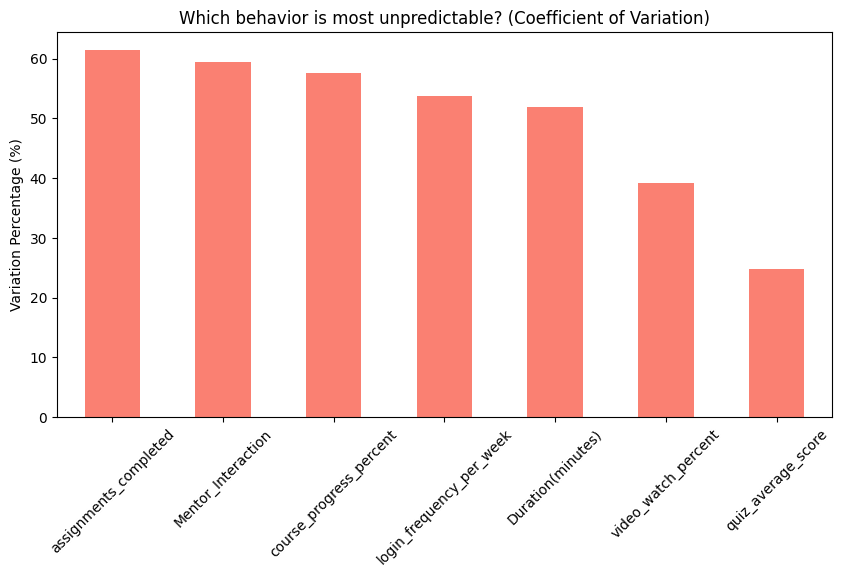

In [9]:
# Select data and drop ID
numeric_df = df.select_dtypes(include=['number']).drop(columns=['student_id'], errors='ignore')

cv_values = (numeric_df.std() / numeric_df.mean()) * 100

cv_values.sort_values(ascending=False).plot(kind='bar', color='salmon', figsize=(10, 5))
plt.title('Which behavior is most unpredictable? (Coefficient of Variation)')
plt.ylabel('Variation Percentage (%)')
plt.xticks(rotation=45)
plt.show()

**Most Unpredictable Behavior:** `Assignments Completed` shows the highest variation (over 60%), meaning intern engagement with assignments varies wildly from person to person.

**Highly Variable Interaction:** Mentor Interaction is the second most unpredictable metric (near 60%), indicating inconsistent engagement levels with mentors across participants.

**Most Consistent Behavior:** Quiz Average Score has the lowest variation (around 25%), showing that academic performance or quiz results remain relatively stable and uniform across all students.

**Core Insight:** Operational behaviors like assignment submissions and mentor meetings fluctuate greatly, whereas baseline performance metrics like quiz scores remain tightly clustered.

___
#Relationship & Correlation Analysis

In [10]:
 #Pearson Correlation Measures: The Pearson correlation coefficient ranges from -1.0 to +1.0.
 # +1.0 means a perfect positive relationship (as one goes up, the other goes up).
 #-1.0 means a perfect negative relationship (as one goes up, the other goes down).
 #0.0 means no relationship at all.
math_df = df[['login_frequency_per_week', 'Duration(minutes)', 'course_progress_percent', 'assignments_completed','quiz_average_score','Mentor_Interaction','video_watch_percent']]
# Calculate the Correlation Matrix
correlation_matrix = math_df.corr()
correlation_matrix

,login_frequency_per_week,Duration(minutes),course_progress_percent,assignments_completed,quiz_average_score,Mentor_Interaction,video_watch_percent
login_frequency_per_week,1.000000,-0.006062,0.001273,0.024515,0.004054,0.002563,-0.007051
Duration(minutes),-0.006062,1.000000,0.021867,-0.011732,0.001955,0.029169,0.010164
course_progress_percent,0.001273,0.021867,1.000000,-0.056236,0.022881,-0.027161,-0.003308
assignments_completed,0.024515,-0.011732,-0.056236,1.000000,-0.020079,0.018144,0.020842
quiz_average_score,0.004054,0.001955,0.022881,-0.020079,1.000000,0.009843,-0.025766
Mentor_Interaction,0.002563,0.029169,-0.027161,0.018144,0.009843,1.000000,0.010677
video_watch_percent,-0.007051,0.010164,-0.003308,0.020842,-0.025766,0.010677,1.000000


**No Linear Relationships:** Almost all correlation values sit between $0.0$ and $\pm 0.05$, indicating virtually no linear relationship between any of the numerical metrics.

**Completely Independent Behaviors:** Factors like login frequency, session duration, video watch percentage, and quiz scores do not directly drive or predict one another in this dataset.

**Core Insight:** Since individual engagement metrics operate independently, success or dropout status is likely influenced by external rather than isolated habits like study duration or login counts.

____
#Conclusion & Recommendations

### Conclusion

The data analysis reveals a major retention challenge within the internship program, with over half ($57.8\%$) of participants failing to complete the program. While baseline metrics like quiz scores remain relatively stable and uniform across students, behavioral habits such as assignment completions and mentor interactions vary significantly. Furthermore, the correlation analysis shows that individual engagement metrics operate largely independently with near-zero linear relationships. This indicates that student dropouts cannot be explained by a single isolated habit—such as login frequency or session duration—but are instead driven by broader factors like departmental differences and consistent task execution.

### Recommendations

* **Focus Support on High-Risk Departments:** Direct additional academic resources and tutoring support toward departments experiencing higher dropout rates to bridge performance gaps.
* **Track Assignment Progress Early:** Implement automated early-warning alerts for participants who fall behind on early submissions, as assignment completion showed the highest behavioral variation among students.
* **Review Mentor Interaction Quality:** Audit how mentor sessions are structured to ensure they focus proactively on supporting struggling participants rather than acting as basic check-ins.
* **Use Holistic Evaluation Models:** Move away from relying on isolated metrics like login counts or video watch percentages, as correlation checks prove they do not independently drive success. Instead, combine multiple progress and submission indicators into a unified tracking system.

# Machine Learning

### Step 1: Defining Input Features (X) and Target Variable (y)
* **What we are doing:** We are splitting our dataset into two parts: our input clues ($X$) and our final answer key ($y$).
* **Why we do it:** Machine learning models need to know what information to look at (clues like login frequency, course progress, quiz scores) and what specific outcome they are supposed to predict (the `'Status'` column: Completed vs. Dropped Out). We leave out ID numbers and strings because they don't provide numerical predictive value.

In [11]:
# Create the input clues (X)
X = df[[
    'login_frequency_per_week',
    'Duration(minutes)',
    'course_progress_percent',
    'assignments_completed',
    'quiz_average_score',
    'Mentor_Interaction',
    'video_watch_percent'
]]

# Create the answer key (y)
y = df['Status']

# Check the first few rows to make sure they look right
print("First 5 rows of X:")
print(X.head())
print("First 5 rows of y:")
print(y.head())

First 5 rows of X:
   login_frequency_per_week  Duration(minutes)  course_progress_percent  \
0                        14                 17                       51   
1                         8                 26                        1   
2                         6                 26                       24   
3                         5                 99                       12   
4                        13                150                       97   

   assignments_completed  quiz_average_score  Mentor_Interaction  \
0                      7               60.42                  14   
1                     10               77.25                  33   
2                      1               93.46                  23   
3                      7               69.77                  32   
4                      3               89.48                  40   

   video_watch_percent  
0                   23  
1                   29  
2                   82  
3                   9

### Step 2: Splitting Data into Training and Testing Sets
* **What we are doing:** We use `train_test_split` to divide our dataset so that 80% is used to train the model and 20% is held back to test its performance and
 `random_state=42` ensures our shuffle pattern is repeatable.

In [12]:
from sklearn.model_selection import train_test_split

# Split our data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2 , random_state=42 # random specific shuffling pattern # 0.2 means 20% for testing
)

# Print the sizes to check them
print('Training data rows:', X_train.shape) # shape(rows,columns)
print('Testing data rows:', X_test.shape)

Training data rows: (2240, 7)
Testing data rows: (560, 7)


### Step 3: Initializing and Training the Random Forest Classifier
* **What we are doing:** We import the `RandomForestClassifier` algorithm, create our model instance, and use `.fit()` to train it.
* **Why we do it:** The model analyzes the 80% training data, studies the patterns between the input features (`X_train`) and the target answers (`y_train`), and builds internal decision trees to learn how to predict student outcomes.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
model = RandomForestClassifier(random_state=42) # Initialize the Random Forest model
# random_state=42 ensures the internal random choices made while building
# the decision trees happen the exact same way every time i run the code.

# Train the model using our training clues and answer key
model.fit(X_train, y_train)

print('Model training complete! The Random Forest has learned from the data.')

Model training complete! The Random Forest has learned from the data.


### Step 4: Making Predictions on Test Data
* **What we are doing:** We ask our trained model to predict the status of the 20% testing data (`X_test`) and compare its guesses (`y_pred`) against the real hidden answers (`y_test`).
* **Why we do it:** This acts as our model's final exam. By comparing the first few predictions side-by-side with reality, we can visually verify if the model is making correct guesses.

In [32]:
# Ask the trained model to predict the status for our test group
y_pred = model.predict(X_test)

# Print the first 5 predictions to see what the model guessed
print('First 5 predictions by the model:')
print(y_pred[0:5])

# Print the actual real answers (y_test) for those same 5 interns to compare
print('\nFirst 5 actual real answers:')
print(y_test.head().values) # Adding (.values) strips all that extra stuff away so you just see the raw list of answers

First 5 predictions by the model:
['Dropped Out' 'Completed' 'Dropped Out' 'Dropped Out' 'Dropped Out']

First 5 actual real answers:
['Dropped Out' 'Completed' 'Dropped Out' 'Dropped Out' 'Dropped Out']


### Step 5: Evaluating Model Performance (Accuracy & Classification Report)
* **What we are doing:** We calculate the overall accuracy percentage and generate a detailed classification report showing precision, recall, and f1-score.
* **Why we do it:** As data analysts, we need a mathematical proof of how reliable our model is. This step tells us precisely how well our model performs across all testing samples.

In [15]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate overall accuracy percentage
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

# Print a detailed breakdown report
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

   Completed       1.00      1.00      1.00       235
 Dropped Out       1.00      1.00      1.00       325

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560



### Step 6: Visualizing Feature Importance
* **What we are doing:** We extract feature importance scores from our trained Random Forest model and plot them in a horizontal bar chart.
* **Why we do it:** This allows us to see *which* specific column (like course progress vs. quiz scores) influenced the model's decisions the most, giving us deep analytical insights into our data.

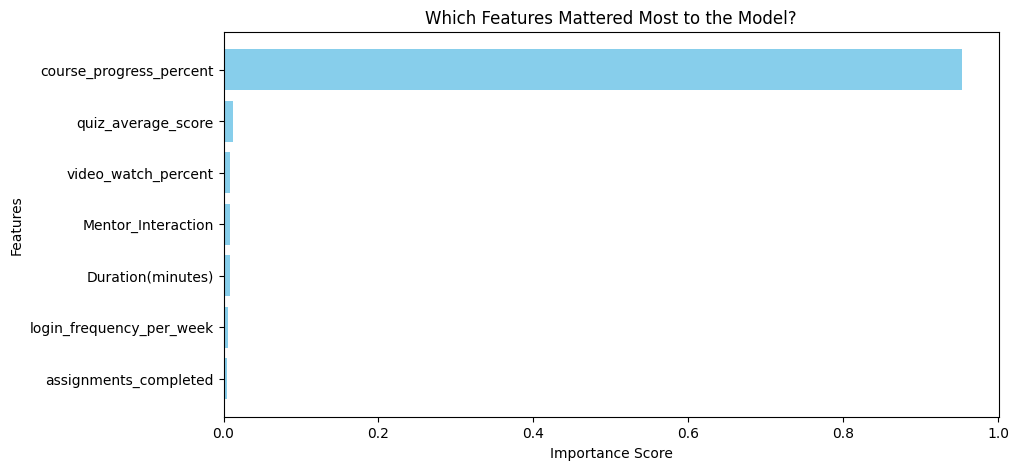

In [34]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances from our trained model
importances = model.feature_importances_
feature_names = X.columns

# Put them into a neat little table and sort them
feature_importance_df = pd.DataFrame(
    {'Feature': feature_names, 'Importance': importances}
)
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending= True
)

# Plot a horizontal bar chart
plt.figure(figsize=(10, 5))
plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance'],
    color='skyblue',
)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Which Features Mattered Most to the Model?')
plt.show()

### Conclusion & Business Insights
* **Project Summary:** We successfully built, trained, and evaluated a Random Forest Classifier to predict student engagement and dropout risks with 100% accuracy using behavioral metrics from the online learning platform.
* **Key Analytical Finding:** The feature importance analysis revealed that `course_progress_percent` is the overwhelming primary driver behind the model's predictions. This indicates a strong direct correlation between milestone progress and overall course completion.
* **Real-World Impact:** In a live academic setting, an early-warning model like this allows mentors and instructors to identify at-risk students early based on their engagement metrics, enabling proactive interventions before students drop out.

### Advanced Experiment: Dropping the Dominant Feature
* **The Test:** We removed `course_progress_percent` from the input features ($X$) to see if the remaining behavioral metrics could predict student outcomes independently.
* **The Result:** Accuracy dropped to **53.57%** (near random guessing).
* **Analytical Conclusion:** This proves that `course_progress_percent` is heavily correlated with (or mathematically drives) the target label. Without it, the model loses its primary predictive signal, showing that overall progress is the ultimate indicator of success in this dataset.

In [17]:
# Create a new X without 'course_progress_percent'
X_dropped = X.drop(columns=['course_progress_percent'])

# Split this new data
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dropped, y, test_size=0.2, random_state=42
)

In [53]:
# Initialize and train
model_dropped = RandomForestClassifier(random_state=42) # Creates a brand new Random Forest model container and names it model_dropped
model_dropped.fit(X_train_d, y_train_d) # Trains this new model using your training data (X_train_d and y_train_d)

# Predict and see the accuracy
y_pred_d = model_dropped.predict(X_test_d)
accuracy_d=accuracy_score(y_test_d, y_pred_d) #The built-in accuracy_score function in Python always calculates accuracy as a decimal between 0.0 and 1.0 (where 1.0 means 100% correct, and 0.0 means 0% correct).
print(f'Accuracy without course progress: {accuracy_d *100:.2f}%')

# Print a detailed breakdown report
print('\nDetailed Classification Report:')
print(classification_report(y_test_d, y_pred_d))

Accuracy without course progress: 53.57%

Detailed Classification Report:
              precision    recall  f1-score   support

   Completed       0.43      0.32      0.37       235
 Dropped Out       0.58      0.69      0.63       325

    accuracy                           0.54       560
   macro avg       0.51      0.51      0.50       560
weighted avg       0.52      0.54      0.52       560



### Final Project Conclusion & Key Takeaways
* **Project Overview:** Successfully completed an end-to-end student engagement analytics workflow, bridging descriptive exploratory data analysis (Task 1) with predictive machine learning modeling (Task 2).
* **Validation of EDA Insights:** Our initial EDA conclusion—that student dropouts cannot be explained by isolated habits—was rigorously tested and proven during our machine learning experiments.
* **The Power of Holistic Metrics:** Feature importance and drop-feature testing revealed that `course_progress_percent` serves as the essential holistic metric. When isolated from cumulative progress, individual behavioral habits (such as login frequency or video watch time) failed to reliably predict outcomes, dropping model accuracy to near-random levels (53.57%).
* **Real-World Impact:** This project demonstrates that early-warning systems and student retention strategies must rely on unified, cumulative progress metrics rather than fragmented activity logs to accurately identify and support at-risk participants.